In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

In [3]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

x = GlobalAveragePooling2D()(base_model.output)

embedding_layer = Dense(
    512,
    activation='relu',
    name='embedding'
)(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=embedding_layer
)

print("MobileNetV2 Loaded Successfully")

MobileNetV2 Loaded Successfully


In [4]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

def extract_embedding(img_path):

    img = load_img(
        img_path,
        target_size=(224,224)
    )

    img = img_to_array(img)

    img = preprocess_input(img)

    img = np.expand_dims(img, axis=0)

    embedding = mobilenet_model.predict(
        img,
        verbose=0
    )[0]

    return embedding

In [5]:
print("MobileNetV2 Parameters:")
print(mobilenet_model.count_params())

MobileNetV2 Parameters:
2913856


In [6]:
sample_image = "../preprocessing/train/" + os.listdir("../preprocessing/train")[0]

start = time.time()

embedding = extract_embedding(sample_image)

end = time.time()

print("Embedding Shape:", embedding.shape)
print("Inference Time:", end-start, "seconds")

Embedding Shape: (512,)
Inference Time: 2.1540534496307373 seconds


In [7]:
import os
from tqdm import tqdm

train_dir = "../preprocessing/train"

sample_files = os.listdir(train_dir)[:100]

mobilenet_embeddings = []

for file in tqdm(sample_files):

    path = os.path.join(train_dir, file)

    emb = extract_embedding(path)

    mobilenet_embeddings.append(emb)

print("Total Embeddings:", len(mobilenet_embeddings))

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:16<00:00,  6.21it/s]

Total Embeddings: 100


In [9]:
mobilenet_df = pd.DataFrame(mobilenet_embeddings)

print(mobilenet_df.shape)

(100, 512)


In [10]:
import os

os.makedirs(
    "../results/week3_results",
    exist_ok=True
)

mobilenet_df.to_csv(
    "../Outputs/Notebook_04/mobilenet_embeddings.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [11]:
comparison = pd.DataFrame({

    "Model": [
        "ResNet50",
        "MobileNetV2"
    ],

    "Parameters": [
        25600000,
        2913856
    ],

    "Embedding Size": [
        512,
        512
    ]
})

comparison

,Model,Parameters,Embedding Size
0,ResNet50,25600000,512
1,MobileNetV2,2913856,512


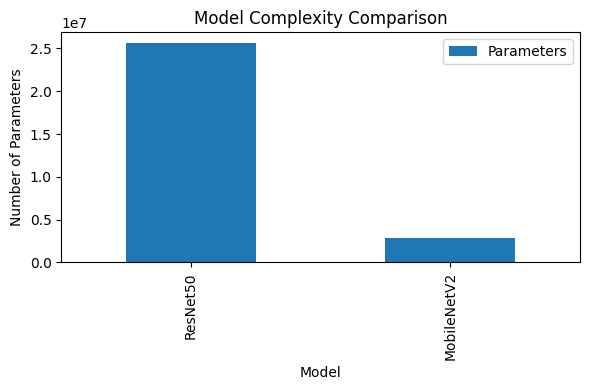

In [13]:
comparison.plot(
    x="Model",
    y="Parameters",
    kind="bar",
    figsize=(6,4)
)

plt.title("Model Complexity Comparison")
plt.ylabel("Number of Parameters")

plt.tight_layout()

plt.savefig(
    "../Outputs/Notebook_04/10.png"
)

plt.show()